## Exploratory Data Analysis (EDA)
Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that involves summarizing the main characteristics of a dataset, often using visual methods. The goal of EDA is to gain insights into the data, identify patterns, detect anomalies, and formulate hypotheses for further analysis.

In [2]:
# libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

In [3]:
# Extract the dataset from the zip file
import zipfile
with zipfile.ZipFile("../data/micro+gas+turbine+electrical+energy+prediction.zip", "r") as zip_ref:
    zip_ref.extractall("../data/")

In [4]:

# Extract the training dataset from the zip file
with zipfile.ZipFile("../data/train.zip", "r") as zip_ref:
    zip_ref.extractall("../data/")

# Extract the test dataset from the zip file
with zipfile.ZipFile("../data/test.zip", "r") as zip_ref:
    zip_ref.extractall("../data/")

In [5]:
# load the dataset
ex_1_df = pd.read_csv("../data/train/ex_1.csv")
ex_1_df.head()

,time,input_voltage,el_power
0,810.07028,10,1228.791720
1,811.06938,10,1223.041745
2,812.06848,10,1244.960866
3,813.06758,10,1229.259058
4,814.06668,10,1248.117024


In [6]:
# change the date column to datetime
ex_1_df["time"] = pd.to_datetime(ex_1_df["time"])
ex_1_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9920 entries, 0 to 9919
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time           9920 non-null   datetime64[ns]
 1   input_voltage  9920 non-null   int64         
 2   el_power       9920 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 232.6 KB


In [7]:
ex_1_df.describe()

,time,input_voltage,el_power
count,9920,9920.000000,9920.000000
mean,1970-01-01 00:00:00.000005764,6.822480,2162.427874
min,1970-01-01 00:00:00.000000810,3.000000,932.837260
25%,1970-01-01 00:00:00.000003286,3.000000,990.027512
50%,1970-01-01 00:00:00.000005764,10.000000,2709.354147
75%,1970-01-01 00:00:00.000008242,10.000000,3116.416457
max,1970-01-01 00:00:00.000010720,10.000000,3249.891217
std,NaN,3.485288,1009.468755


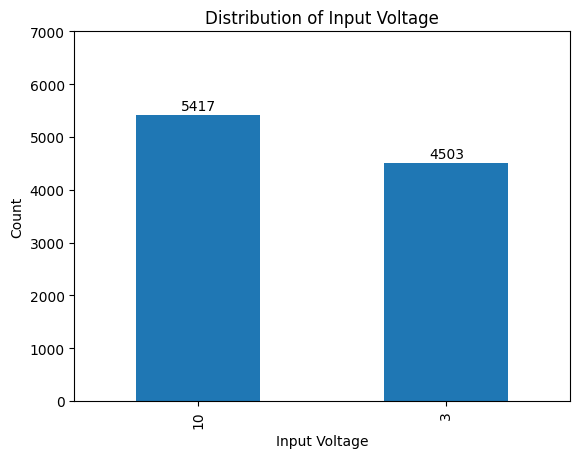

In [8]:
ex_1_df.value_counts('input_voltage').plot(kind='bar')
plt.title('Distribution of Input Voltage')
plt.xlabel('Input Voltage')
plt.ylabel('Count')
plt.ylim(0, 7000)

for index, value in enumerate(ex_1_df.value_counts('input_voltage')):
    plt.text(index, value + 100, str(value), ha='center')

plt.show()

In [9]:
# Check time range
print(f"Time range: {ex_1_df['time'].min()} to {ex_1_df['time'].max()}")

Time range: 1970-01-01 00:00:00.000000810 to 1970-01-01 00:00:00.000010720


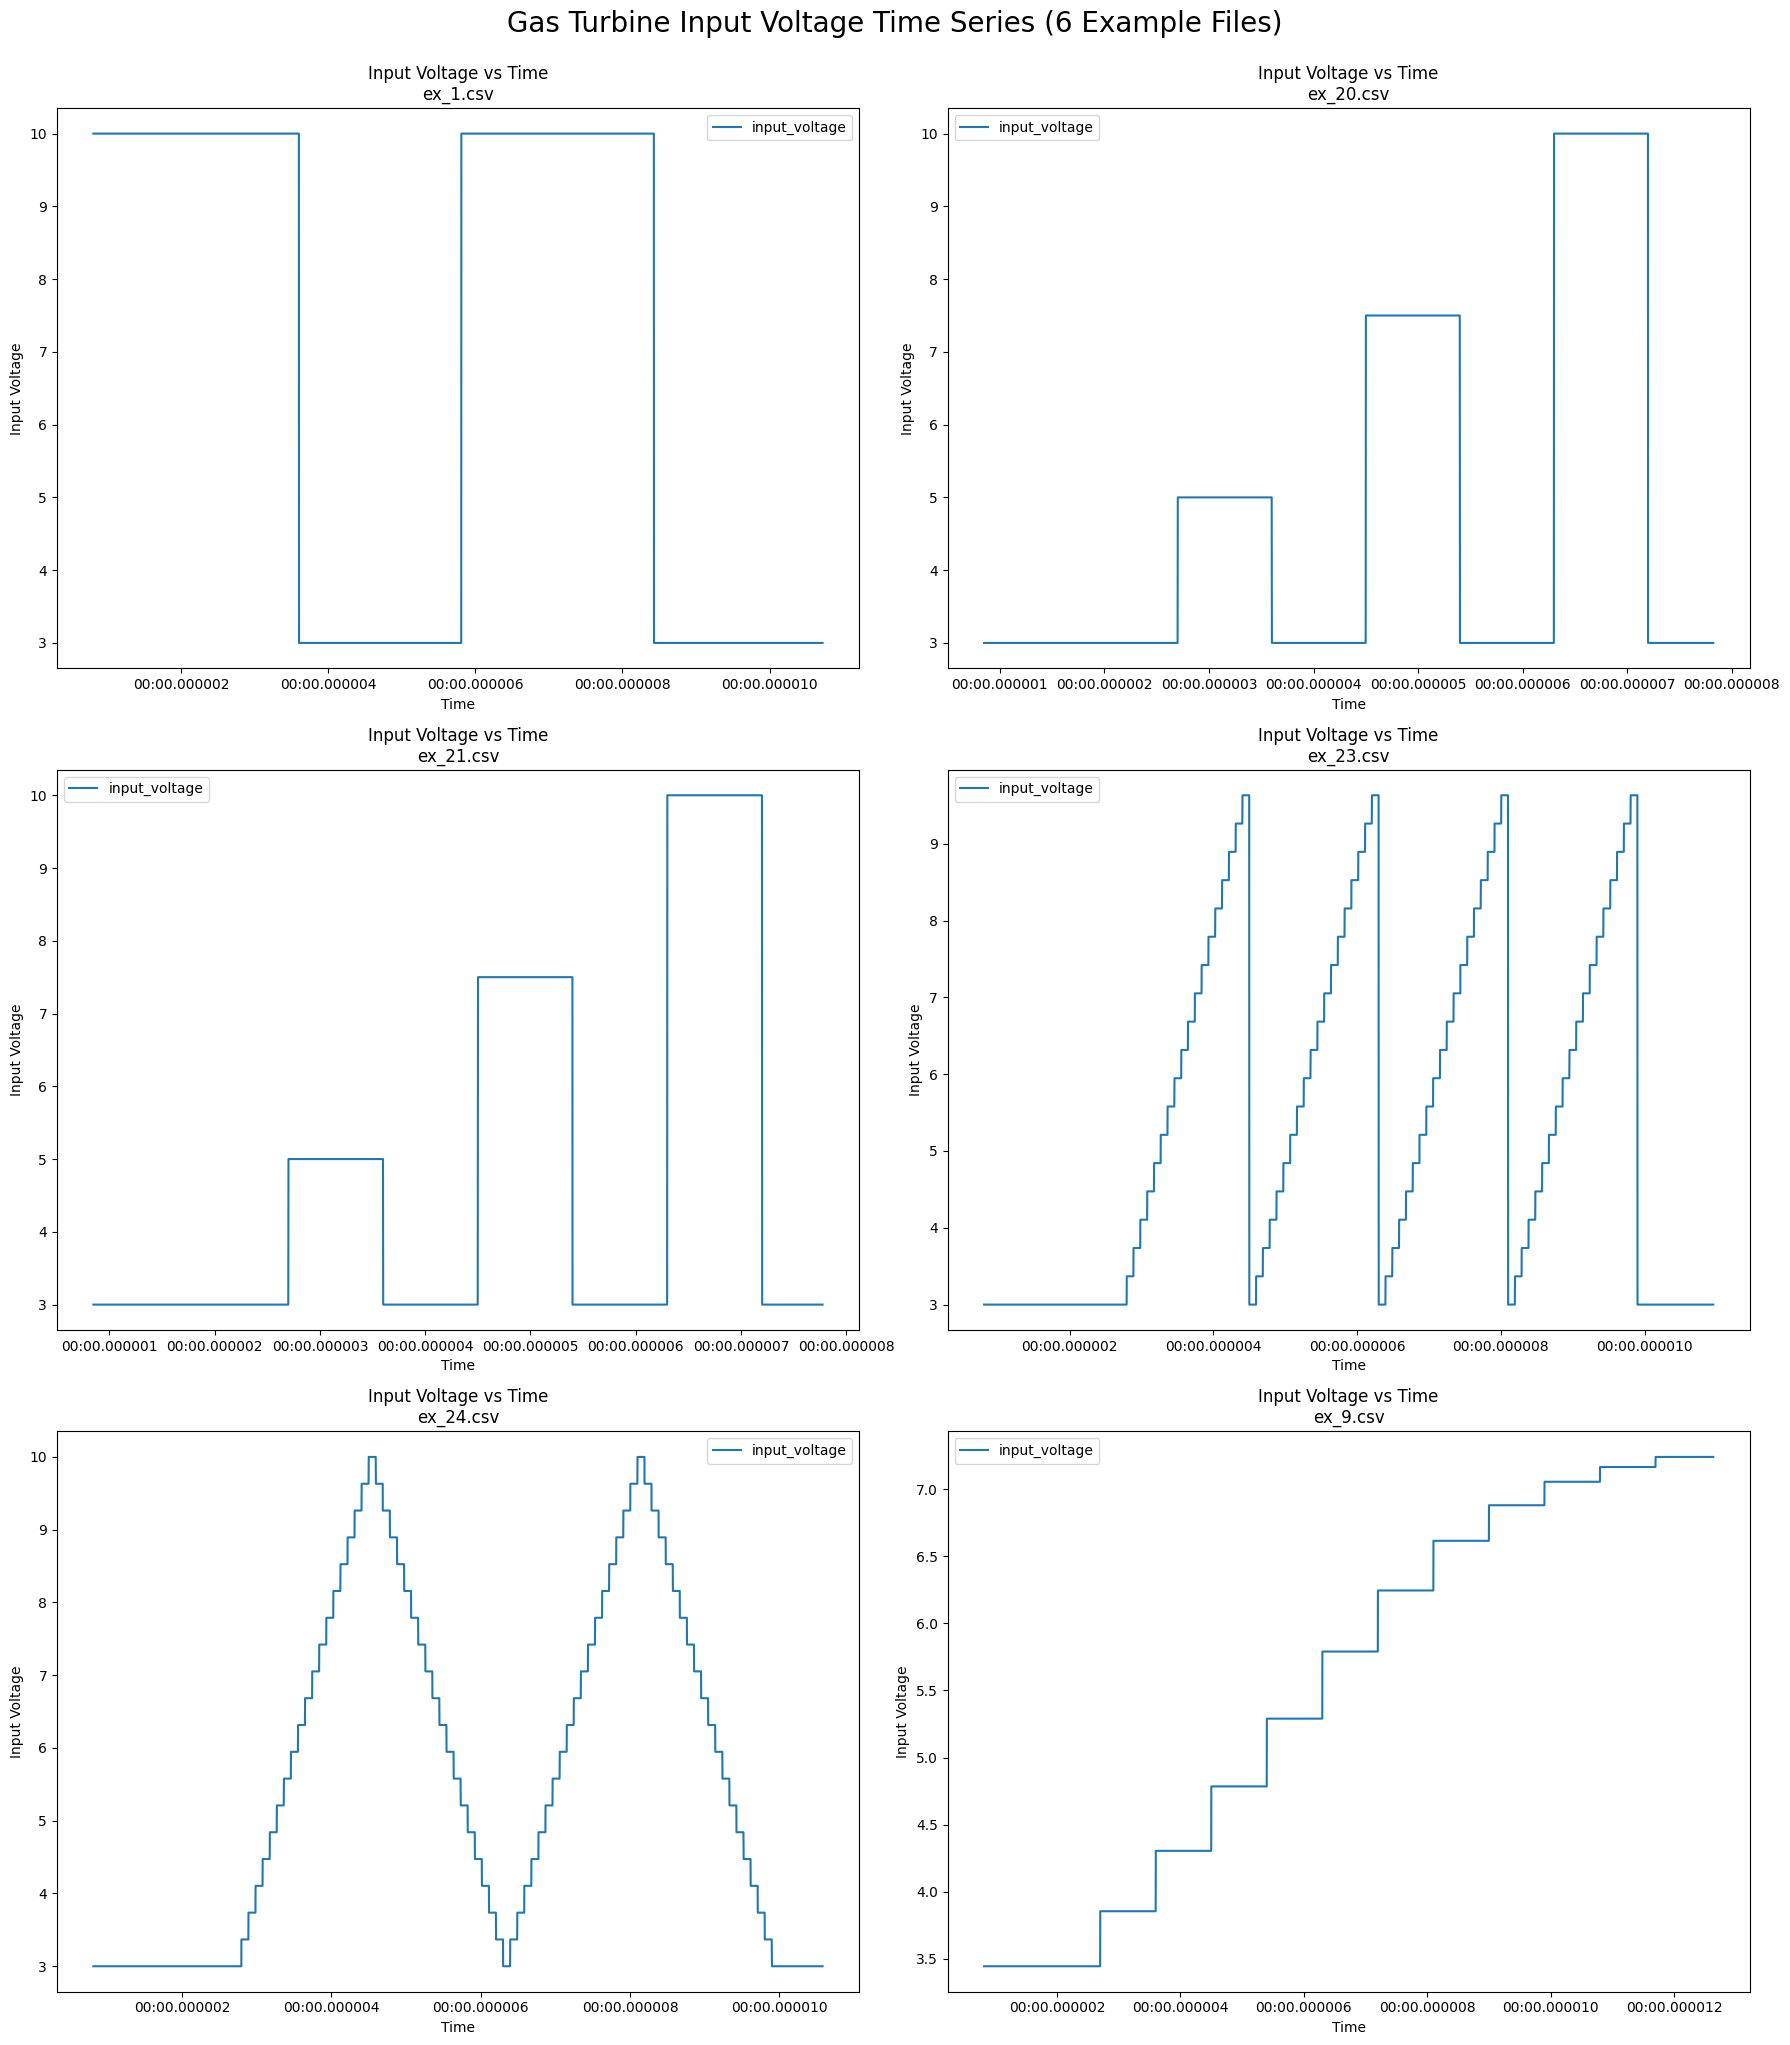

In [10]:
# High-level technical time series plots for 6 example files
import matplotlib.pyplot as plt
import pandas as pd
import glob
example_files = [
    '../data/train/ex_1.csv',
    '../data/train/ex_20.csv',
    '../data/train/ex_21.csv',
    '../data/train/ex_23.csv',
    '../data/train/ex_24.csv',
    '../data/train/ex_9.csv'
 ]

plt.figure(figsize=(18, 20))
for i, file in enumerate(example_files, 1):
    data = pd.read_csv(file)
    data['time'] = pd.to_datetime(data['time'])
    plt.subplot(3, 2, i)
    plt.plot(data['time'], data['input_voltage'], label='input_voltage')
    plt.xlabel('Time')
    plt.ylabel('Input Voltage')
    plt.title(f'Input Voltage vs Time\n{file.split('/')[-1]}')
    plt.legend()
    plt.tight_layout()
plt.suptitle('Gas Turbine Input Voltage Time Series (6 Example Files)', fontsize=20, y=1.02)
plt.show()

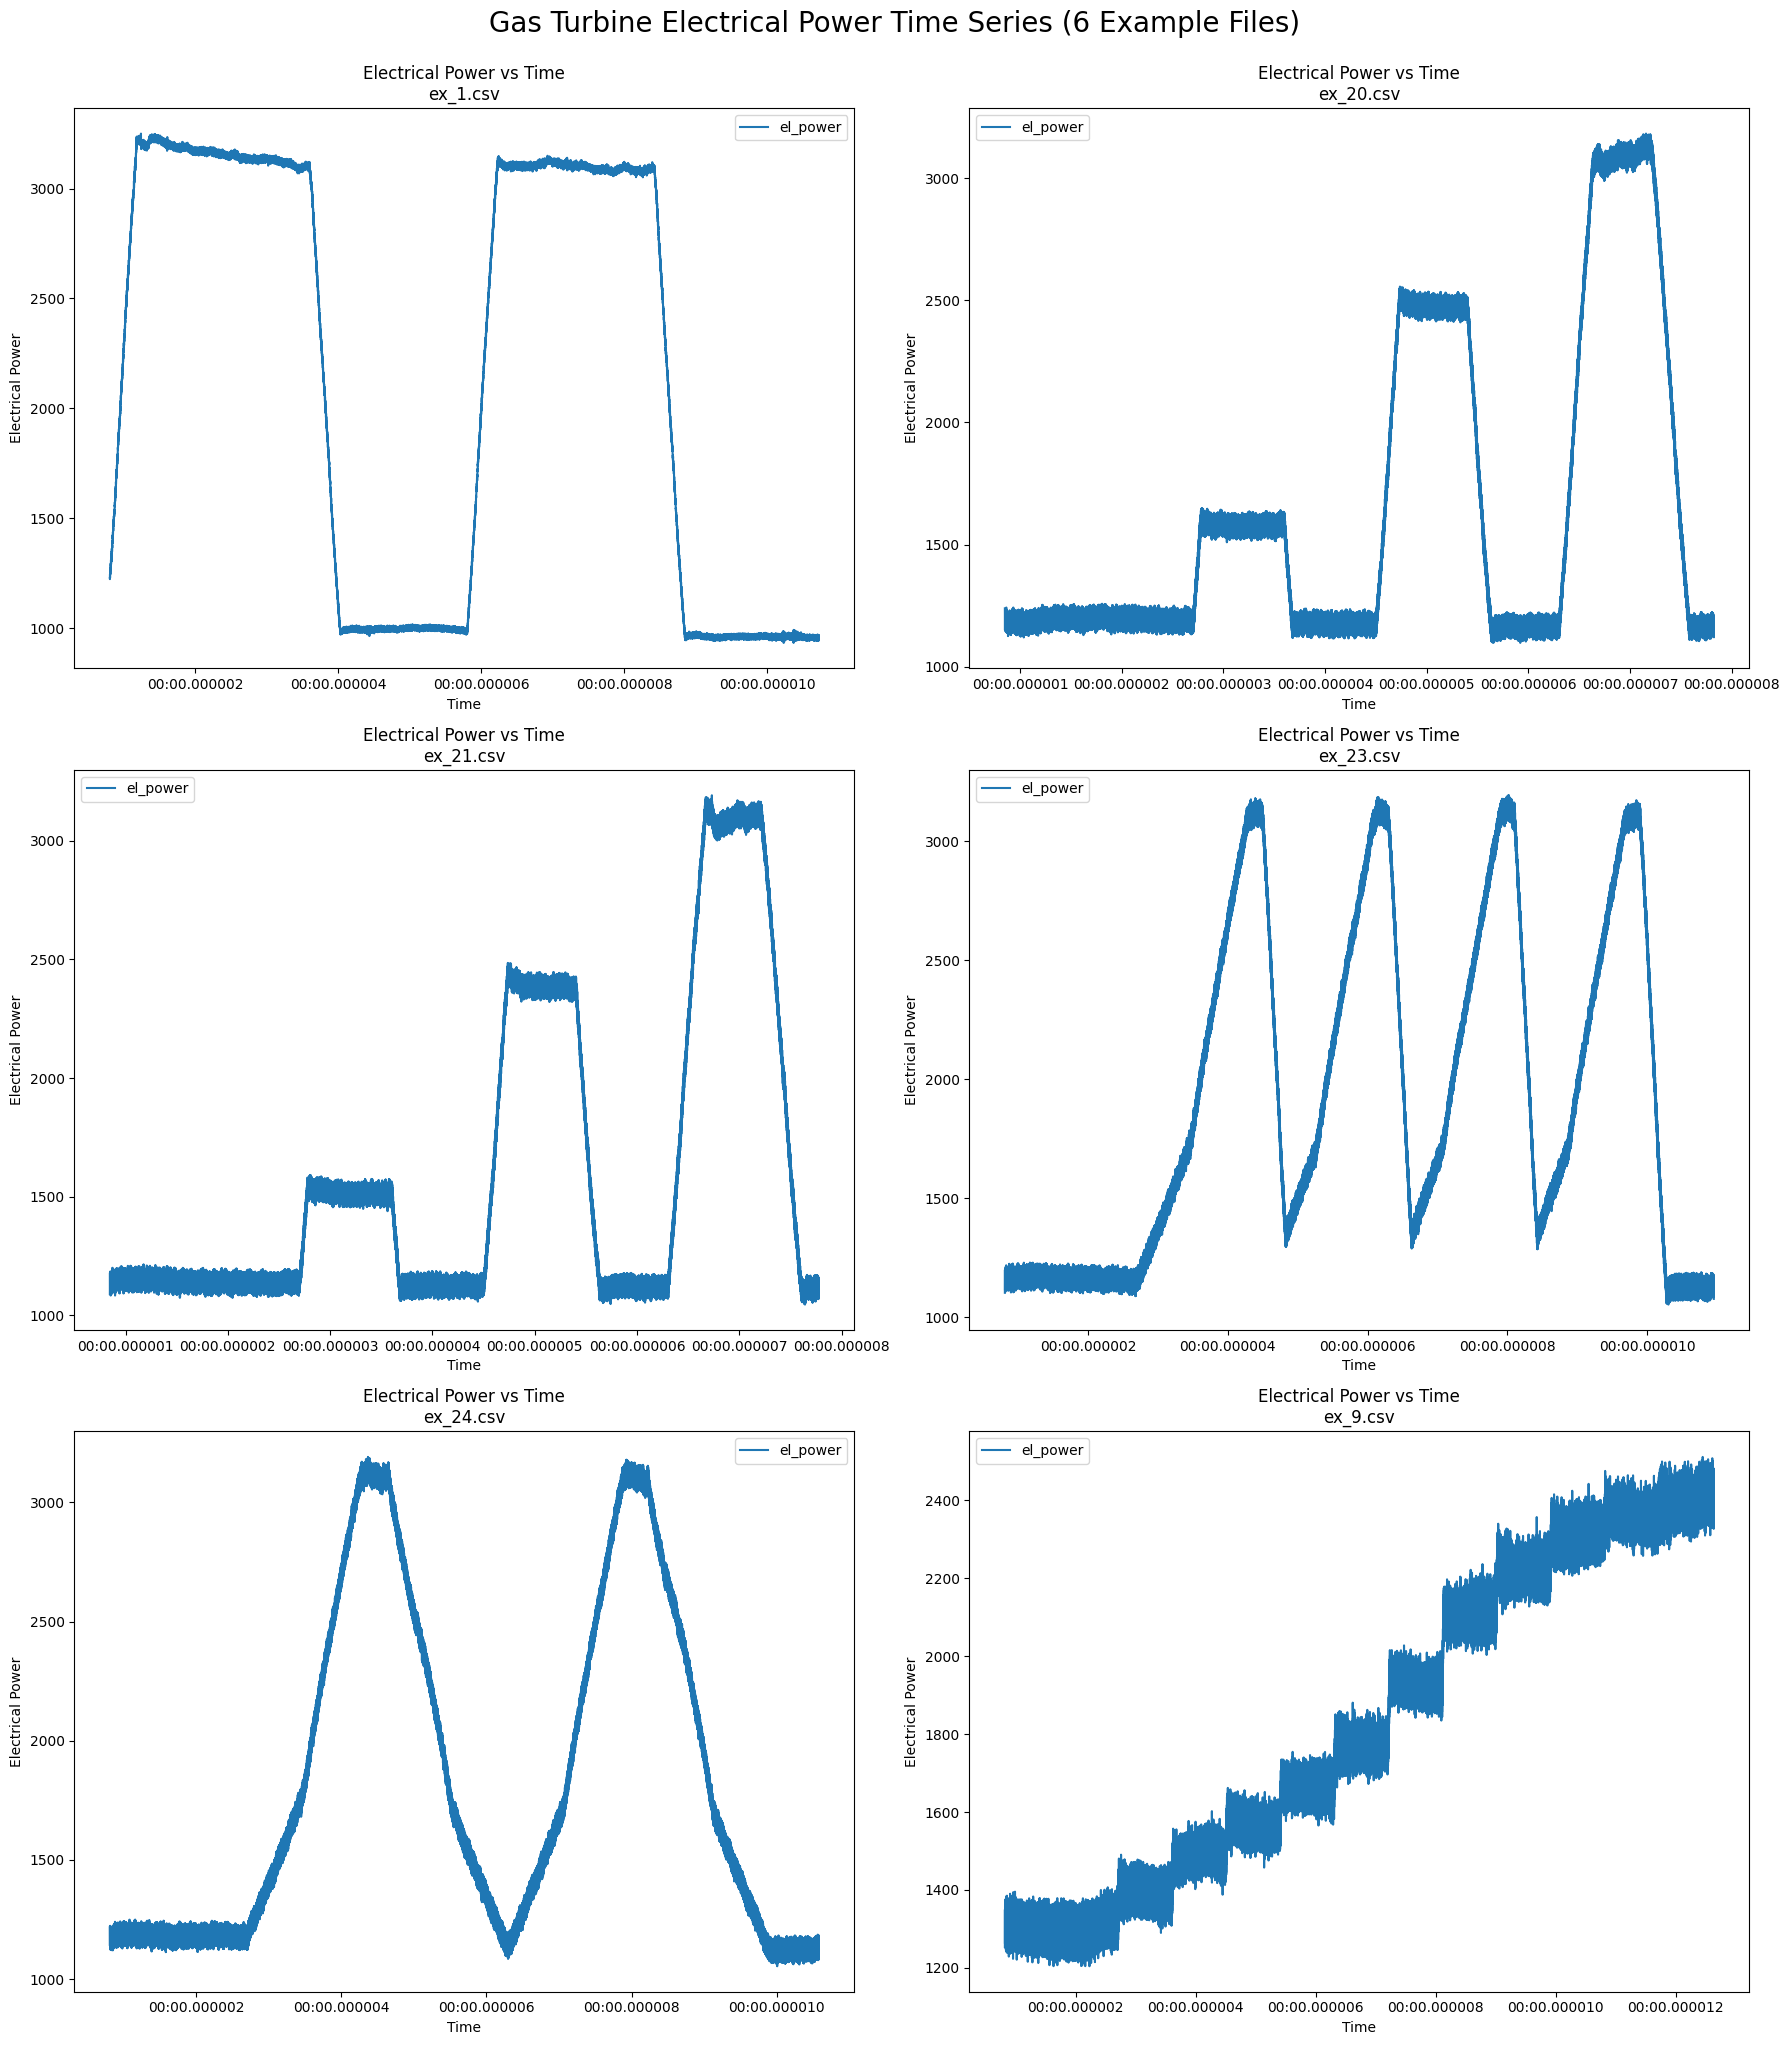

In [11]:
plt.figure(figsize=(18, 20))
for i, file in enumerate(example_files, 1):
    data = pd.read_csv(file)
    data['time'] = pd.to_datetime(data['time'])
    plt.subplot(3, 2, i)
    plt.plot(data['time'], data['el_power'], label='el_power')
    plt.xlabel('Time')
    plt.ylabel('Electrical Power')
    plt.title(f'Electrical Power vs Time\n{file.split('/')[-1]}')
    plt.legend()
    plt.tight_layout()
plt.suptitle('Gas Turbine Electrical Power Time Series (6 Example Files)', fontsize=20, y=1.02)
plt.show()

In [17]:
# count number of distinct Input Voltage values per file
values_list = []

for c, file in enumerate(example_files, 1):
    data = pd.read_csv(file)
    counts = data["input_voltage"].value_counts()   # frequencies per voltage value
    values_list.append({
        "file": file,
        "n_distinct_input_voltage": data["input_voltage"].nunique(),
        "counts": counts
    })

values_list

[{'file': '../data/train/ex_1.csv',
  'n_distinct_input_voltage': 2,
  'counts': input_voltage
  10    5417
  3     4503
  Name: count, dtype: int64},
 {'file': '../data/train/ex_20.csv',
  'n_distinct_input_voltage': 4,
  'counts': input_voltage
  3.0     4070
  5.0      843
  7.5      804
  10.0     778
  Name: count, dtype: int64},
 {'file': '../data/train/ex_21.csv',
  'n_distinct_input_voltage': 4,
  'counts': input_voltage
  3.0     4061
  5.0      848
  7.5      811
  10.0     775
  Name: count, dtype: int64},
 {'file': '../data/train/ex_23.csv',
  'n_distinct_input_voltage': 19,
  'counts': input_voltage
  3.000000    3126
  4.105263     358
  4.473684     356
  5.210526     352
  5.578947     351
  4.842105     349
  3.736842     348
  5.947368     347
  6.684211     346
  6.315789     344
  7.052632     343
  3.368421     336
  7.421053     332
  7.789474     326
  8.157895     323
  8.526316     316
  8.894737     313
  9.631579     313
  9.263158     309
  Name: count, dtyp

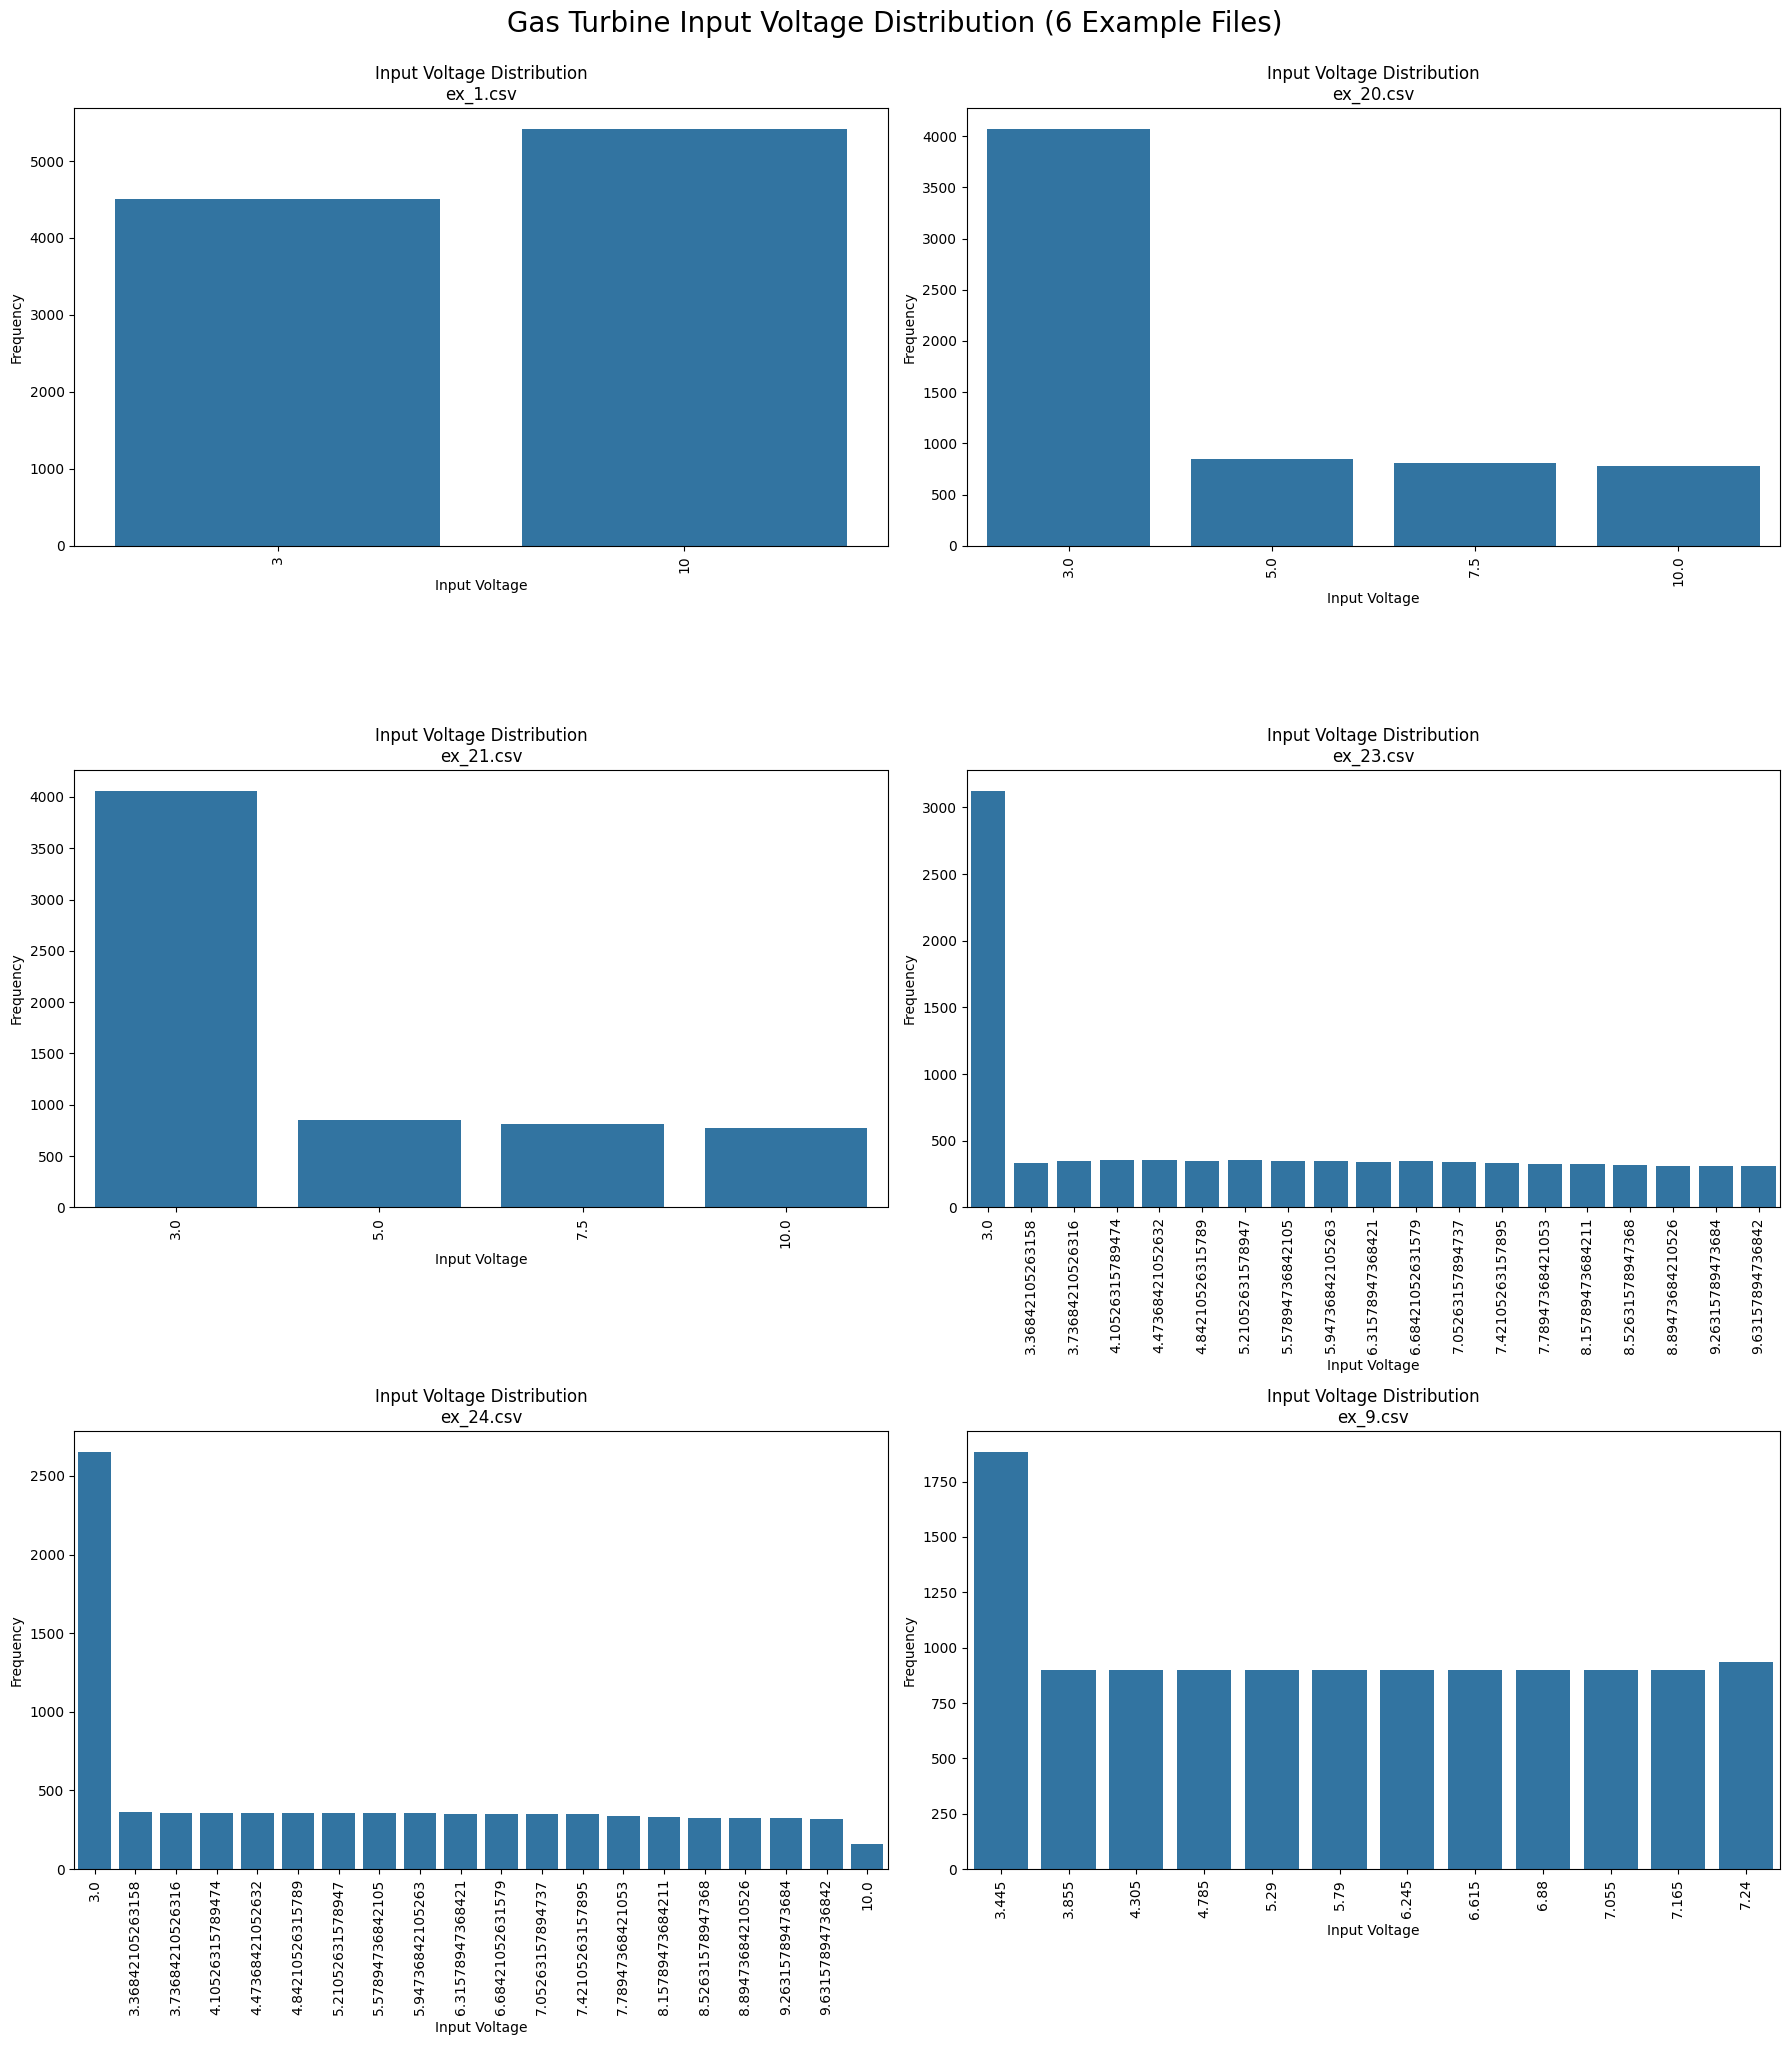

In [18]:
# plot input voltage for 6 example files
plt.figure(figsize=(18, 20))
for i, file in enumerate(example_files, 1):
    data = pd.read_csv(file)
    plt.subplot(3, 2, i)
    sns.barplot(x=data['input_voltage'].value_counts().index, 
                y=data['input_voltage'].value_counts().values)
    plt.xlabel('Input Voltage')
    plt.ylabel('Frequency')
    # rotate x-axis labels
    plt.xticks(rotation=90)
    plt.title(f'Input Voltage Distribution\n{file.split("/")[-1]}')
    plt.tight_layout()
plt.suptitle('Gas Turbine Input Voltage Distribution (6 Example Files)', fontsize=20, y=1.02)
plt.show()